In [14]:
import random
import math
import matplotlib.pyplot as plt

def lcg(n, a, b, M, seed):
    X=seed
    samples = []
    for i in range(n):
        X = (a * X + b) % M
        samples.append(X/M)
    return samples

#samples = lcg(10000, 1664525, 1013904223, 2**32, 42)
samples_bad = lcg(10_000, a=3, b=0, M=2048, seed=1)

def lcg(seed, a=1664525, b=1013904223, M=2**32):
    return (a * seed + b) % M

def uniform(seed):
    seed = lcg(seed)
    return seed, seed / (2**32)

def exp_sample(lam, seed):
    # Inverse transform: X = -ln(U) / lambda
    seed, u = uniform(seed)
    return seed, -math.log(u) / lam

## Exercise 7


In [15]:
import math
import matplotlib.pyplot as plt

# --- Generate n random cities in the plane ---
def generate_cities(n, seed=42):
    """Generate n random (x, y) coordinates."""
    cities = []
    s = seed
    for _ in range(n):
        s, x = uniform(s)
        s, y = uniform(s)
        cities.append((x, y))
    return cities

def euclidean(city_a, city_b):
    """Euclidean distance between two cities."""
    return math.sqrt((city_a[0]-city_b[0])**2 + (city_a[1]-city_b[1])**2)

def route_cost(route, cities):
    """Total travel cost of a route (returns to start at the end)."""
    total = 0.0
    n = len(route)
    for i in range(n):
        total += euclidean(cities[route[i]], cities[route[(i+1) % n]])
    return total

# Test with 20 random cities
n_cities = 20
cities = generate_cities(n_cities, seed=42)
initial_route = list(range(n_cities))  # start with route 0,1,2,...,n-1
print(f"Number of cities  : {n_cities}")
print(f"Initial route cost: {route_cost(initial_route, cities):.4f}")

Number of cities  : 20
Initial route cost: 11.5958


In [16]:
def propose_swap(route, seed):
    """
    Propose a new route by swapping two randomly chosen cities.
    """
    n = len(route)
    # Pick two different positions
    seed, u1 = uniform(seed)
    seed, u2 = uniform(seed)
    i = int(u1 * n)
    j = int(u2 * n)
    # Make sure they're different
    while j == i:
        seed, u2 = uniform(seed)
        j = int(u2 * n)
    # Swap
    new_route = route[:]
    new_route[i], new_route[j] = new_route[j], new_route[i]
    return seed, new_route

def simulated_annealing_tsp(cities, n_iterations=50000, cooling='sqrt', seed=42):
    """
    Simulated annealing for TSP.
    
    cooling: 'sqrt' uses T_k = 1/sqrt(1+k)
             'log'  uses T_k = 1/log(2+k)
    """
    n = len(cities)
    
    # Start with route 0,1,2,...,n-1
    route = list(range(n))
    current_cost = route_cost(route, cities)
    
    best_route = route[:]
    best_cost  = current_cost
    
    cost_history = [current_cost]
    
    for k in range(n_iterations):
        # Cooling schedule
        if cooling == 'sqrt':
            T = 1.0 / math.sqrt(1 + k)
        else:  # log
            T = 1.0 / math.log(2 + k)
        
        # Propose a swap
        seed, new_route = propose_swap(route, seed)
        new_cost = route_cost(new_route, cities)
        
        # Accept or reject (SA acceptance rule)
        delta = new_cost - current_cost
        if delta <= 0:
            # Better route — always accept
            route = new_route
            current_cost = new_cost
        else:
            # Worse route — accept with probability exp(-delta/T)
            seed, u = uniform(seed)
            if u < math.exp(-delta / T):
                route = new_route
                current_cost = new_cost
        
        # Track the best route ever found
        if current_cost < best_cost:
            best_cost  = current_cost
            best_route = route[:]
        
        cost_history.append(current_cost)
    
    return best_route, best_cost, cost_history

# Run it
best_route, best_cost, cost_history = simulated_annealing_tsp(
    cities, n_iterations=50000, cooling='sqrt', seed=42
)
print(f"Initial cost : {route_cost(list(range(n_cities)), cities):.4f}")
print(f"Best cost    : {best_cost:.4f}")
print(f"Best route   : {best_route}")

Initial cost : 11.5958
Best cost    : 3.6422
Best route   : [8, 13, 15, 0, 2, 14, 3, 7, 10, 1, 11, 17, 5, 12, 9, 4, 16, 19, 18, 6]


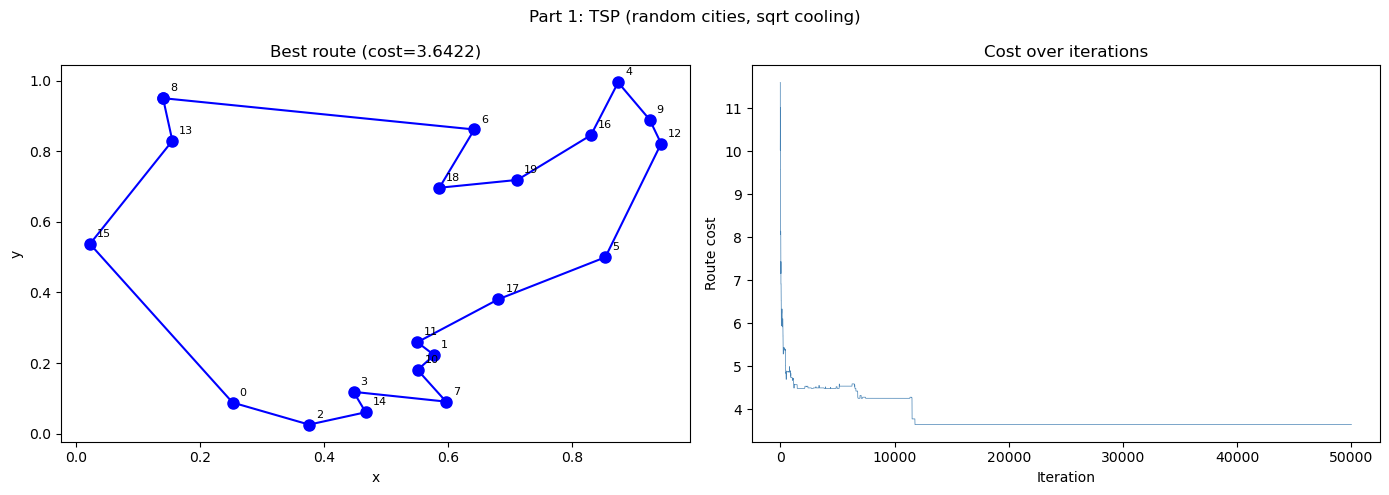

In [17]:
def plot_tsp_result(cities, best_route, cost_history, title='TSP Result'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Left: the route ---
    route_closed = best_route + [best_route[0]]  # close the loop
    xs = [cities[i][0] for i in route_closed]
    ys = [cities[i][1] for i in route_closed]
    
    axes[0].plot(xs, ys, 'b-o', markersize=8, zorder=2)
    for idx, (x, y) in enumerate(cities):
        axes[0].annotate(str(idx), (x, y), textcoords='offset points',
                         xytext=(5, 5), fontsize=8)
    axes[0].set_title(f'Best route (cost={min(cost_history):.4f})')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    
    # --- Right: cost over iterations ---
    axes[1].plot(cost_history, color='steelblue', linewidth=0.5)
    axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel('Route cost')
    axes[1].set_title('Cost over iterations')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_tsp_result(cities, best_route, cost_history, title='Part 1: TSP (random cities, sqrt cooling)')

Optimal cost (theory): 6.2374
SA best cost         : 6.2374
Match: True


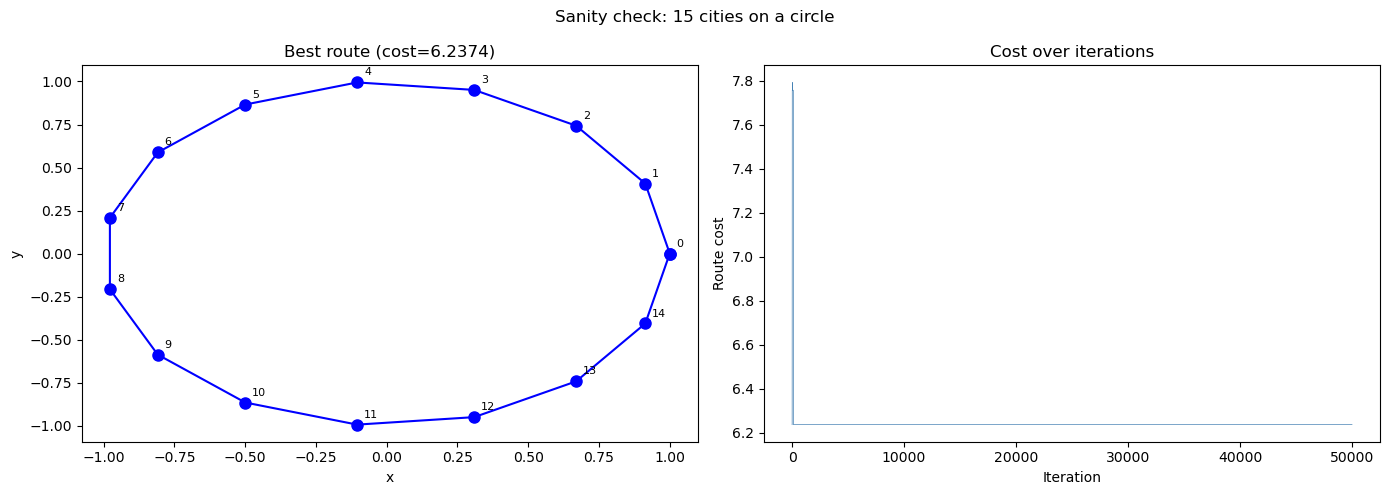

In [18]:
def generate_circle_cities(n):
    """
    Place n cities evenly on a unit circle.
    The optimal route is to visit them in order — a perfect circle.
    """
    cities = []
    for i in range(n):
        angle = 2 * math.pi * i / n
        cities.append((math.cos(angle), math.sin(angle)))
    return cities

# The optimal cost for n points on a unit circle
# is n * 2 * sin(pi/n) (chord length times n)
n_circle = 15
circle_cities = generate_circle_cities(n_circle)
optimal_cost = n_circle * 2 * math.sin(math.pi / n_circle)

best_route_c, best_cost_c, cost_history_c = simulated_annealing_tsp(
    circle_cities, n_iterations=50000, cooling='sqrt', seed=42
)

print(f"Optimal cost (theory): {optimal_cost:.4f}")
print(f"SA best cost         : {best_cost_c:.4f}")
print(f"Match: {abs(best_cost_c - optimal_cost) < 0.001}")

plot_tsp_result(circle_cities, best_route_c, cost_history_c,
                title=f'Sanity check: {n_circle} cities on a circle')

In [19]:
# --- Load the cost matrix ---
def load_cost_matrix(filepath):
    matrix = []
    with open(filepath, 'r') as f:
        for line in f:
            row = [int(x) for x in line.strip().split(',')]
            matrix.append(row)
    return matrix

cost_matrix = load_cost_matrix(r'C:\Users\nourm\OneDrive\Skrivebord\stoc_sim\cost.csv')
n_matrix = len(cost_matrix)
print(f"Number of cities: {n_matrix}")
print(f"Matrix size: {n_matrix}x{len(cost_matrix[0])}")

def route_cost_matrix(route, matrix):
    """Total cost of a route using a cost matrix."""
    total = 0
    n = len(route)
    for i in range(n):
        total += matrix[route[i]][route[(i+1) % n]]
    return total

# Check initial route cost
initial_route_m = list(range(n_matrix))
print(f"Initial route cost: {route_cost_matrix(initial_route_m, cost_matrix)}")

def simulated_annealing_matrix(matrix, n_iterations=100000, cooling='sqrt', seed=42):
    """
    SA for TSP using a cost matrix instead of Euclidean distances.
    Everything else is identical to Part 1.
    """
    n = len(matrix)
    route = list(range(n))
    current_cost = route_cost_matrix(route, matrix)
    
    best_route = route[:]
    best_cost  = current_cost
    cost_history = [current_cost]
    
    for k in range(n_iterations):
        if cooling == 'sqrt':
            T = 1.0 / math.sqrt(1 + k)
        else:
            T = 1.0 / math.log(2 + k)
        
        # Propose swap
        seed, new_route = propose_swap(route, seed)
        new_cost = route_cost_matrix(new_route, matrix)
        
        delta = new_cost - current_cost
        if delta <= 0:
            route = new_route
            current_cost = new_cost
        else:
            seed, u = uniform(seed)
            if u < math.exp(-delta / T):
                route = new_route
                current_cost = new_cost
        
        if current_cost < best_cost:
            best_cost  = current_cost
            best_route = route[:]
        
        cost_history.append(current_cost)
    
    return best_route, best_cost, cost_history

# Run with sqrt cooling
best_route_m, best_cost_m, history_m = simulated_annealing_matrix(
    cost_matrix, n_iterations=100000, cooling='sqrt', seed=42
)
print(f"\nSqrt cooling:")
print(f"Initial cost : {route_cost_matrix(list(range(n_matrix)), cost_matrix)}")
print(f"Best cost    : {best_cost_m}")
print(f"Best route   : {[x+1 for x in best_route_m]}")  # +1 for 1-indexed cities

# Run with log cooling
best_route_log, best_cost_log, history_log = simulated_annealing_matrix(
    cost_matrix, n_iterations=100000, cooling='log', seed=42
)
print(f"\nLog cooling:")
print(f"Best cost    : {best_cost_log}")
print(f"Best route   : {[x+1 for x in best_route_log]}")

Number of cities: 20
Matrix size: 20x20
Initial route cost: 3404

Sqrt cooling:
Initial cost : 3404
Best cost    : 1218
Best route   : [1, 2, 9, 14, 19, 15, 12, 6, 13, 18, 7, 3, 11, 20, 17, 10, 16, 5, 8, 4]

Log cooling:
Best cost    : 1218
Best route   : [1, 2, 9, 14, 19, 15, 12, 6, 13, 18, 7, 3, 11, 20, 17, 10, 16, 5, 8, 4]


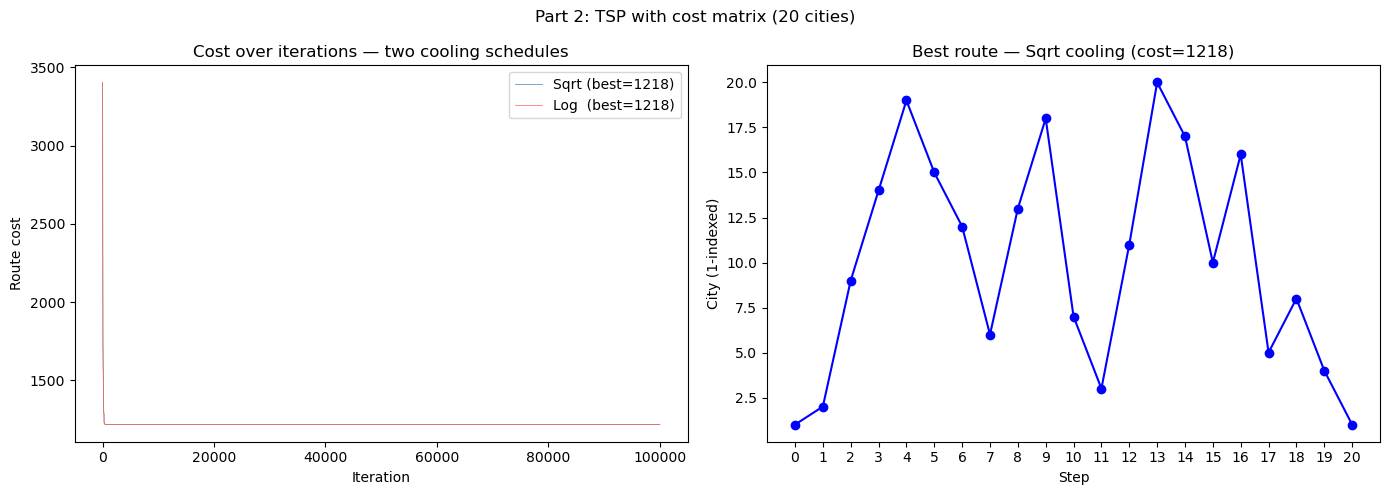

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cost history comparison
axes[0].plot(history_m,   color='steelblue', linewidth=0.5, label=f'Sqrt (best={best_cost_m})')
axes[0].plot(history_log, color='tomato',    linewidth=0.5, label=f'Log  (best={best_cost_log})')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Route cost')
axes[0].set_title('Cost over iterations — two cooling schedules')
axes[0].legend()

# Best route (whichever is better)
if best_cost_m <= best_cost_log:
    best_overall = best_route_m
    best_label   = f'Sqrt cooling (cost={best_cost_m})'
else:
    best_overall = best_route_log
    best_label   = f'Log cooling (cost={best_cost_log})'

# Plot route as sequence of city numbers
route_closed = best_overall + [best_overall[0]]
axes[1].plot(range(len(route_closed)), 
             [x+1 for x in route_closed], 
             'b-o', markersize=6)
axes[1].set_xlabel('Step')
axes[1].set_ylabel('City (1-indexed)')
axes[1].set_title(f'Best route — {best_label}')
axes[1].set_xticks(range(len(route_closed)))

plt.suptitle('Part 2: TSP with cost matrix (20 cities)')
plt.tight_layout()
plt.show()

In [21]:
# Print the best route clearly
best = [1, 2, 9, 14, 19, 15, 12, 6, 13, 18, 7, 3, 11, 20, 17, 10, 16, 5, 8, 4]
route_str = ' → '.join(str(c) for c in best) + ' → ' + str(best[0])
print(f"Best route: {route_str}")
print(f"Best cost : 1218")
print(f"Initial cost: 3404")
print(f"Improvement : {(3404-1218)/3404*100:.1f}%")

Best route: 1 → 2 → 9 → 14 → 19 → 15 → 12 → 6 → 13 → 18 → 7 → 3 → 11 → 20 → 17 → 10 → 16 → 5 → 8 → 4 → 1
Best cost : 1218
Initial cost: 3404
Improvement : 64.2%


## Exercise 8 
## part 1

In [22]:
def lcg(seed):
    a = 1664525
    b = 1013904223
    M = 2**32
    return (a * seed + b) % M

def uniform(seed):
    seed = lcg(seed)
    return seed, seed / 2**32

In [23]:
def bootstrap_sample(data, seed):
    """Draw n items from data with replacement using LCG."""
    n = len(data)
    sample = []
    for _ in range(n):
        seed, u = uniform(seed)
        idx = int(u * n)
        sample.append(data[idx])
    return sample, seed

In [24]:
def bootstrap_estimate_p(data, a, b, k, seed=42):
    """
    Estimate p = P{a < X_bar* - X_bar < b} using k bootstrap replicates.
    X_bar is the sample mean of the original data (our estimate of mu).
    """
    n = len(data)
    x_bar = sum(data) / n  # our estimate of mu

    count = 0
    for _ in range(k):
        resample, seed = bootstrap_sample(data, seed)
        x_bar_star = sum(resample) / n
        diff = x_bar_star - x_bar
        if a < diff < b:
            count += 1

    p_hat = count / k
    return x_bar, p_hat

# Run it
data = [56, 101, 78, 67, 93, 87, 64, 72, 80, 69]
a, b = -5, 5
k = 10000

x_bar, p_hat = bootstrap_estimate_p(data, a, b, k, seed=42)

print(f"Sample mean (estimate of mu) : {x_bar:.2f}")
print(f"Bootstrap estimate of p      : {p_hat:.4f}")

Sample mean (estimate of mu) : 76.70
Bootstrap estimate of p      : 0.7651


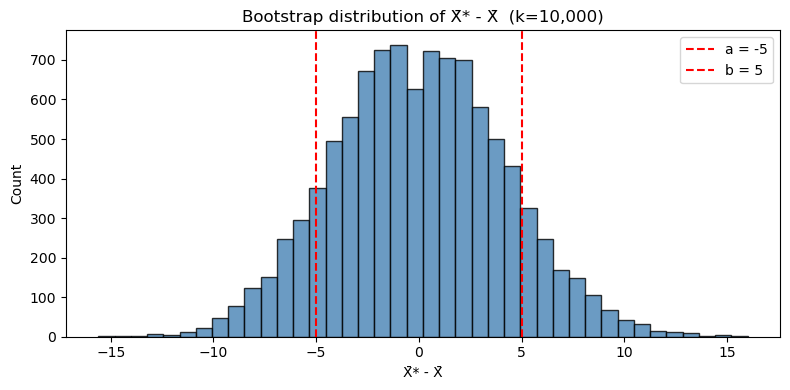

In [25]:
import matplotlib.pyplot as plt

def bootstrap_diffs(data, k, seed=42):
    n = len(data)
    x_bar = sum(data) / n
    diffs = []
    for _ in range(k):
        resample, seed = bootstrap_sample(data, seed)
        x_bar_star = sum(resample) / n
        diffs.append(x_bar_star - x_bar)
    return diffs

diffs = bootstrap_diffs(data, k=10000)

plt.figure(figsize=(8, 4))
plt.hist(diffs, bins=40, edgecolor='black', color='steelblue', alpha=0.8)
plt.axvline(-5, color='red', linestyle='--', label='a = -5')
plt.axvline( 5, color='red', linestyle='--', label='b = 5')
plt.xlabel('X̄* - X̄')
plt.ylabel('Count')
plt.title('Bootstrap distribution of X̄* - X̄  (k=10,000)')
plt.legend()
plt.tight_layout()
plt.show()

## Part 2

In [26]:
def sample_variance(data):
    n = len(data)
    mean = sum(data) / n
    return sum((x - mean)**2 for x in data) / (n - 1)

In [27]:
def bootstrap_var_s2(data, k, seed=42):
    """
    Estimate Var(S^2) using k bootstrap replicates.
    Each replicate: resample data, compute S^2, then take variance of all S^2 values.
    """
    s2_values = []
    for _ in range(k):
        resample, seed = bootstrap_sample(data, seed)
        s2_values.append(sample_variance(resample))

    # mean of bootstrap S^2 values
    s2_bar = sum(s2_values) / k
    # variance of bootstrap S^2 values
    var_s2 = sum((s - s2_bar)**2 for s in s2_values) / (k - 1)

    return s2_bar, var_s2, s2_values

data = [5, 4, 9, 6, 21, 17, 11, 20, 7, 10, 21, 15, 13, 16, 8]
k = 10000

s2_original = sample_variance(data)
s2_bar, var_s2_hat, s2_values = bootstrap_var_s2(data, k, seed=42)

print(f"Original S²              : {s2_original:.4f}")
print(f"Mean of bootstrap S²*    : {s2_bar:.4f}")
print(f"Bootstrap estimate Var(S²): {var_s2_hat:.4f}")

Original S²              : 34.3143
Mean of bootstrap S²*    : 32.0036
Bootstrap estimate Var(S²): 57.7486


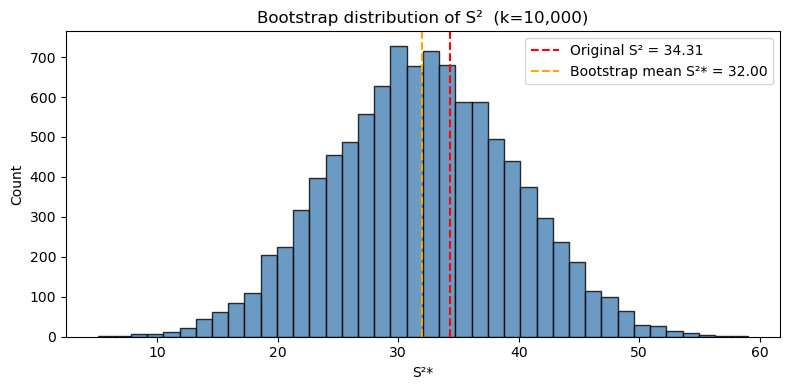

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(s2_values, bins=40, edgecolor='black', color='steelblue', alpha=0.8)
plt.axvline(s2_original, color='red', linestyle='--', label=f'Original S² = {s2_original:.2f}')
plt.axvline(s2_bar, color='orange', linestyle='--', label=f'Bootstrap mean S²* = {s2_bar:.2f}')
plt.xlabel('S²*')
plt.ylabel('Count')
plt.title('Bootstrap distribution of S²  (k=10,000)')
plt.legend()
plt.tight_layout()
plt.show()

## Part 3

In [29]:
def sample_pareto(beta, k, n, seed=42):
    samples = []
    for _ in range(n):
        seed, u = uniform(seed)
        x = beta / (u ** (1.0 / k))
        samples.append(x)
    return samples, seed

In [30]:
def sample_median(data):
    n = len(data)
    sorted_data = sorted(data)
    if n % 2 == 1:
        return sorted_data[n // 2]
    else:
        return (sorted_data[n // 2 - 1] + sorted_data[n // 2]) / 2

In [31]:
def bootstrap_variance(data, estimator, k, seed=42):
    """
    General bootstrap: apply any estimator to k resamples, return variance.
    """
    estimates = []
    for _ in range(k):
        resample, seed = bootstrap_sample(data, seed)
        estimates.append(estimator(resample))
    
    mean_est = sum(estimates) / k
    var_est = sum((e - mean_est)**2 for e in estimates) / (k - 1)
    return var_est, estimates

In [32]:
# Generate Pareto data
pareto_data, _ = sample_pareto(beta=1, k=1.05, n=200, seed=42)

# Point estimates
mean_estimator = lambda data: sum(data) / len(data)
s_mean = mean_estimator(pareto_data)
s_median = sample_median(pareto_data)

# Bootstrap variances
var_mean,   mean_estimates   = bootstrap_variance(pareto_data, mean_estimator, k=100, seed=42)
var_median, median_estimates = bootstrap_variance(pareto_data, sample_median,  k=100, seed=42)

print(f"Sample mean              : {s_mean:.4f}")
print(f"Sample median            : {s_median:.4f}")
print(f"Bootstrap Var(mean)      : {var_mean:.4f}")
print(f"Bootstrap Var(median)    : {var_median:.4f}")
print(f"Ratio Var(mean)/Var(median): {var_mean/var_median:.4f}")

Sample mean              : 4.4090
Sample median            : 1.8075
Bootstrap Var(mean)      : 0.3315
Bootstrap Var(median)    : 0.0109
Ratio Var(mean)/Var(median): 30.5261


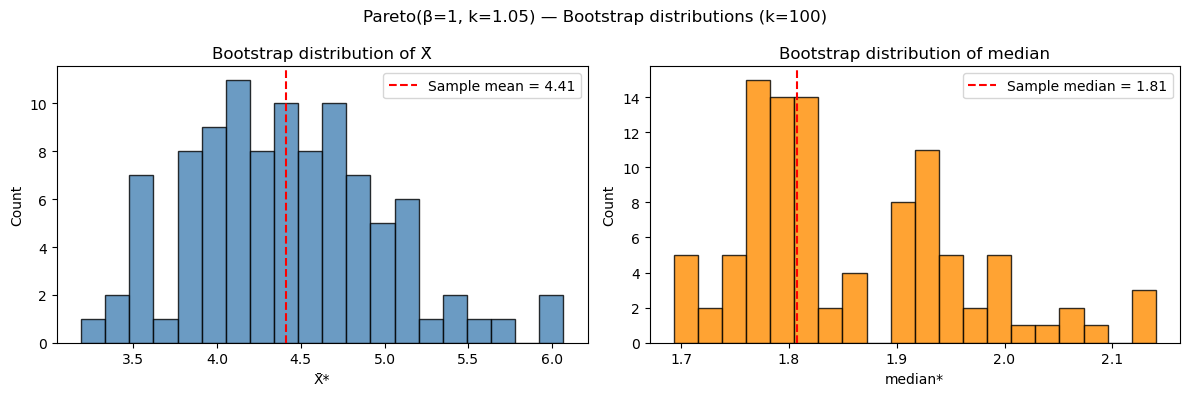

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(mean_estimates, bins=20, edgecolor='black', color='steelblue', alpha=0.8)
axes[0].axvline(s_mean, color='red', linestyle='--', label=f'Sample mean = {s_mean:.2f}')
axes[0].set_title('Bootstrap distribution of X̄')
axes[0].set_xlabel('X̄*')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(median_estimates, bins=20, edgecolor='black', color='darkorange', alpha=0.8)
axes[1].axvline(s_median, color='red', linestyle='--', label=f'Sample median = {s_median:.2f}')
axes[1].set_title('Bootstrap distribution of median')
axes[1].set_xlabel('median*')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Pareto(β=1, k=1.05) — Bootstrap distributions (k=100)', fontsize=12)
plt.tight_layout()
plt.show()